# Root-Lorentzian pulse shapes

Plot the proposed root-Lorentzian pulse and an echoed root-Lorentzian version from the bundle parameters.

In [7]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

from bundle_utils import load_bundle
from presentation_style import polish_axes, presentation_figure, use_presentation_style

use_presentation_style()

PROJECT_DIR = Path.cwd()
DATA_PATH = PROJECT_DIR / "data" / "echo_lorentzian_17-31-02-832822_data_bundle.npz"
FIGURES_DIR = PROJECT_DIR / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

bundle = load_bundle(DATA_PATH)
parameters = bundle.parameters

parameters

{'multiplexed': False,
 'use_state_discrimination': True,
 'reset_type': 'active',
 'qubits': None,
 'num_shots': 20,
 'operation': 'lorentzian',
 'pulse_shape': 'root_lorentzian',
 'lorentzian_length_in_ns': 20000,
 'waveform_template_length_in_ns': 20000,
 'lorentzian_tau_in_ns': 8.0,
 'lorentzian_peak_amplitude': 1,
 'cutoff': 0.99,
 'echo': False,
 'min_amp_factor': 0.0,
 'max_amp_factor': 1.0,
 'amp_factor_step': 0.005,
 'frequency_span_in_mhz': 600,
 'frequency_step_in_mhz': 1,
 'simulate': False,
 'simulation_duration_ns': 50000,
 'use_waveform_report': True,
 'timeout': 120,
 'load_data_id': None}

In [8]:
length_ns = int(parameters["lorentzian_length_in_ns"])
tau_ns = float(parameters["lorentzian_tau_in_ns"])
peak_amplitude = float(parameters["lorentzian_peak_amplitude"])

time_ns = np.arange(length_ns, dtype=float)
time_us = time_ns / 1000
centered_time_ns = time_ns - 0.5 * (length_ns - 1)
centered_time_us = centered_time_ns / 1000

lorentzian = 1 / (1 + (centered_time_ns / tau_ns) ** 2)
root_lorentzian = peak_amplitude * np.sqrt(lorentzian)

echo_root_lorentzian = root_lorentzian.copy()
echo_root_lorentzian[len(echo_root_lorentzian) // 2 :] *= -1

print(f"Length: {length_ns / 1000:g} us")
print(f"Tau: {tau_ns:g} ns")
print(f"Peak amplitude: {root_lorentzian.max():.6f}")
print(f"Edge amplitude: {root_lorentzian[0]:.6e}")

Length: 20 us
Tau: 8 ns
Peak amplitude: 0.998053
Edge amplitude: 8.000397e-04


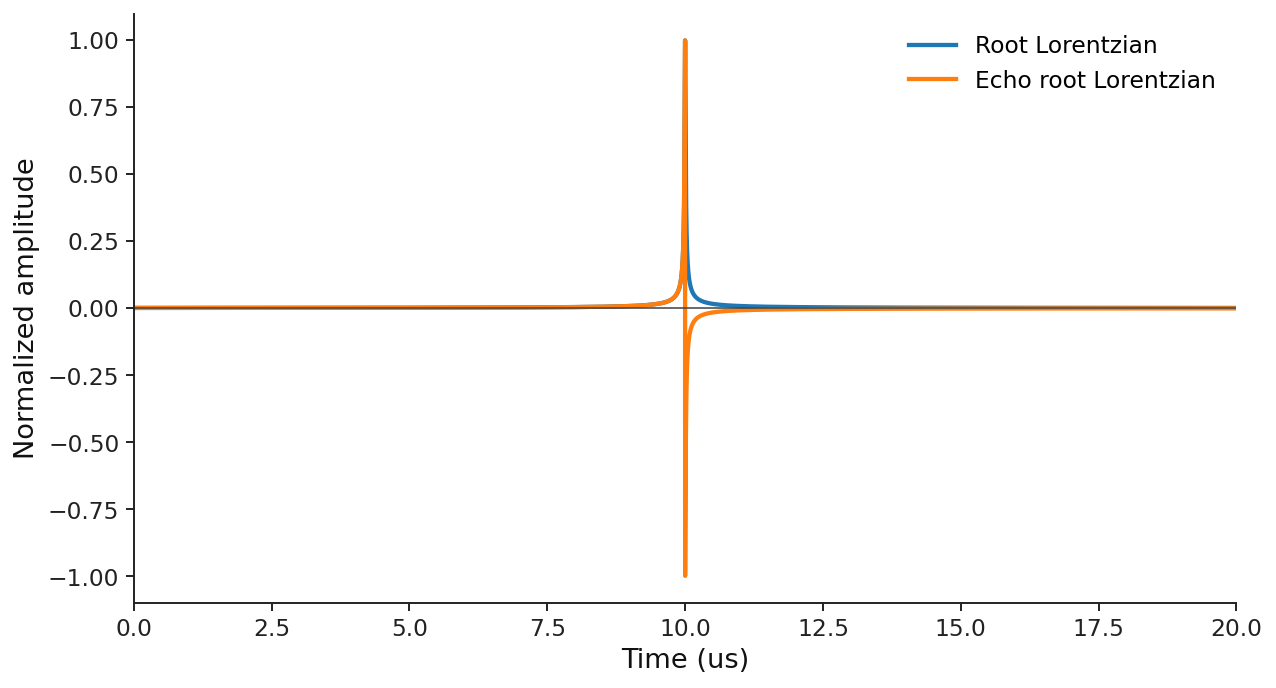

Saved PNG: C:\Users\owner\Developer\ips_plots\figures\01_root_lorentzian_pulses.png
Saved PDF: C:\Users\owner\Developer\ips_plots\figures\01_root_lorentzian_pulses.pdf


In [9]:
fig, ax = presentation_figure(width=9.0, height=4.8)

ax.plot(time_us, root_lorentzian, linewidth=2.2, label="Root Lorentzian")
ax.plot(time_us, echo_root_lorentzian, linewidth=2.2, label="Echo root Lorentzian")
ax.axhline(0, color="#444444", linewidth=1.0, alpha=0.8)
ax.set_xlim(0, length_ns / 1000)

ax.set_xlabel("Time (us)")
ax.set_ylabel("Normalized amplitude")
ax.legend(loc="upper right")
polish_axes(ax)

figure_stem = FIGURES_DIR / "01_root_lorentzian_pulses"
png_path = figure_stem.with_suffix(".png")
pdf_path = figure_stem.with_suffix(".pdf")
fig.canvas.draw()
fig.savefig(png_path, dpi=300, bbox_inches="tight", facecolor="white")
fig.savefig(pdf_path, bbox_inches="tight", facecolor="white")

plt.show()

print(f"Saved PNG: {png_path.resolve()}")
print(f"Saved PDF: {pdf_path.resolve()}")

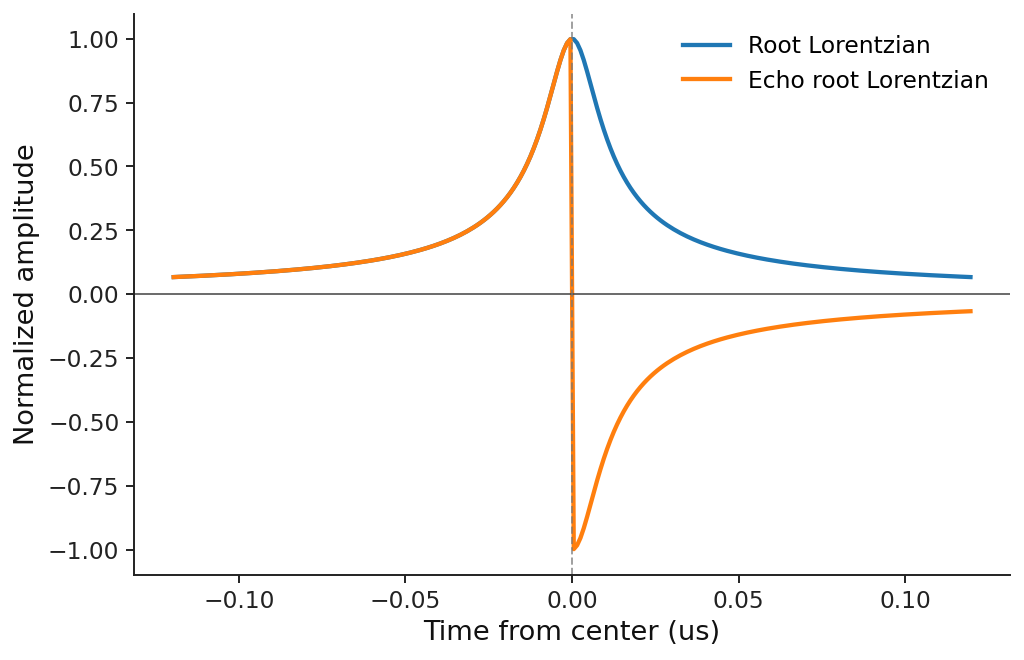

Saved PNG: C:\Users\owner\Developer\ips_plots\figures\01_root_lorentzian_pulses_zoom.png
Saved PDF: C:\Users\owner\Developer\ips_plots\figures\01_root_lorentzian_pulses_zoom.pdf


In [10]:
zoom_half_width_ns = 120
zoom_mask = np.abs(centered_time_ns) <= zoom_half_width_ns

fig, ax = presentation_figure(width=7.2, height=4.6)

ax.plot(centered_time_us[zoom_mask], root_lorentzian[zoom_mask], linewidth=2.2, label="Root Lorentzian")
ax.plot(centered_time_us[zoom_mask], echo_root_lorentzian[zoom_mask], linewidth=2.2, label="Echo root Lorentzian")
ax.axhline(0, color="#444444", linewidth=1.0, alpha=0.8)
ax.axvline(0, color="#777777", linewidth=1.0, linestyle="--", alpha=0.7)

ax.set_xlabel("Time from center (us)")
ax.set_ylabel("Normalized amplitude")
ax.legend(loc="upper right")
polish_axes(ax)

figure_stem = FIGURES_DIR / "01_root_lorentzian_pulses_zoom"
zoom_png_path = figure_stem.with_suffix(".png")
zoom_pdf_path = figure_stem.with_suffix(".pdf")
fig.canvas.draw()
fig.savefig(zoom_png_path, dpi=300, bbox_inches="tight", facecolor="white")
fig.savefig(zoom_pdf_path, bbox_inches="tight", facecolor="white")

plt.show()

print(f"Saved PNG: {zoom_png_path.resolve()}")
print(f"Saved PDF: {zoom_pdf_path.resolve()}")